In [1]:
# 기존 패키지와의 충돌 방지를 위해 transformers와 accelerate 버전을 명시하여 설치
!pip install -q transformers==4.46.3 accelerate==0.34.2 bitsandbytes==0.45.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


# **Mobile VLM + Clip Text Encoder 불러오기**
- https://github.com/Meituan-AutoML/MobileVLM

> **Mobile VLM 불러오기**

In [2]:
%cd /content
!rm -rf MobileVLM
!git clone https://github.com/Meituan-AutoML/MobileVLM.git

/content
Cloning into 'MobileVLM'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 212 (delta 61), reused 41 (delta 41), pack-reused 128 (from 1)
Receiving objects: 100% (212/212), 474.57 KiB | 33.90 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [3]:
import sys
import torch
sys.path.append("/content/MobileVLM")

from mobilevlm.model.mobilevlm import load_pretrained_model

model_path = "mtgv/MobileVLM-3B"
tokenizer, model, image_processor, context_len = load_pretrained_model( model_path, device="cuda" )

model.to(torch.bfloat16)
print(f"✅ 로드 성공! VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

tokenizer_config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.07G [00:00<?, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:769: UserWarning: for vision_model.embeddings.class_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:769: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:769: UserWarning: for vision_model.embeddings.posi

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

✅ 로드 성공! VRAM: 5.68 GB


> **Clip Text Encoder 불러오기**

- MobileVLM의 vision_tower는 Pretrain된 CLIP vision encoder에서 text encoder 부분을 제외한 파라미터를 그대로 사용한다.
- CLIP을 활용한 이미지-텍스트 간 유사도 계산을 하기 위해 Pretrained Clip에서 Text Encoder 부분만을 추가로 불러온다.

In [4]:
# =====================================================================
# Clip Text Encoder만 추가 로드 (Vision Encoder는 MobileVLM 것 재사용)
# pruning 이전 시점 — model 변수를 참조 (pruned_model 아직 없음)
# =====================================================================
import torch
import torch.nn.functional as F
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import hf_hub_download
from PIL import Image
from safetensors.torch import load_file as safe_load_file

clip_ckpt = "openai/clip-vit-large-patch14-336"

# ------------------------------------------------------------------
# 1. Vision Encoder: model(pruning 전)에 이미 로드된 것을 "참조"만 함
#    이 객체는 pruning 이후에도 그대로 재사용됩니다 (vision_tower는 pruning 대상 아님)
# ------------------------------------------------------------------
_clip_vision_model = model.model.vision_tower.vision_tower   # ⬅ pruned_model이 아니라 model
_clip_vision_model.eval()
print("✅ vision encoder: model의 것을 그대로 참조 (pruning 후에도 재사용 예정)")

# ------------------------------------------------------------------
# 2. Text Encoder: MobileVLM에는 없는 부분이라 별도 로드 (불가피)
# ------------------------------------------------------------------
clip_text_model = CLIPTextModel.from_pretrained(
    clip_ckpt, torch_dtype=torch.bfloat16
).to("cuda").eval()
clip_tokenizer = CLIPTokenizer.from_pretrained(clip_ckpt)
print("✅ text_model: 공식 CLIP text encoder 로드 완료")

# ------------------------------------------------------------------
# 3. Projection matrices + logit_scale만 별도 로드
# ------------------------------------------------------------------
try:
    ckpt_path = hf_hub_download(clip_ckpt, "model.safetensors")
    sd = safe_load_file(ckpt_path)
except Exception:
    ckpt_path = hf_hub_download(clip_ckpt, "pytorch_model.bin")
    sd = torch.load(ckpt_path, map_location="cpu")

visual_projection = torch.nn.Linear(
    sd["visual_projection.weight"].shape[1],
    sd["visual_projection.weight"].shape[0], bias=False
)
visual_projection.weight.data = sd["visual_projection.weight"].clone()
visual_projection = visual_projection.to("cuda", dtype=torch.bfloat16)

text_projection = torch.nn.Linear(
    sd["text_projection.weight"].shape[1],
    sd["text_projection.weight"].shape[0], bias=False
)
text_projection.weight.data = sd["text_projection.weight"].clone()
text_projection = text_projection.to("cuda", dtype=torch.bfloat16)

logit_scale = sd["logit_scale"].to("cuda")

del sd
torch.cuda.empty_cache()
print("✅ projection + logit_scale 로드 완료")

✅ vision encoder: model의 것을 그대로 참조 (pruning 후에도 재사용 예정)


tokenizer_config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ text_model: 공식 CLIP text encoder 로드 완료
✅ projection + logit_scale 로드 완료


> **Total Parameter Before Pruning**

In [4]:
# =====================================================================
# 전체 파라미터 개수 집계 (vision encoder 중복 로드 없는 버전)
# =====================================================================

def count_params(m):
    total  = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.3f}B"
    if n >= 1e6: return f"{n/1e6:.3f}M"
    return f"{n:,}"

print("=" * 60)
print("📊 로드된 모델 파라미터 집계")
print("=" * 60)

# ── 1. MobileVLM 전체 ──────────────────────────────────────────────
mv_total, mv_train = count_params(model)
print(f"\n[MobileVLM-3B 전체]")
print(f"  total     : {fmt(mv_total)}")
print(f"  trainable : {fmt(mv_train)}")

# language model만 따로 (vision_tower / mm_projector 제외)
lm_params = sum(
    p.numel()
    for name, p in model.named_parameters()
    if not name.startswith("model.vision_tower")
    and not name.startswith("model.mm_projector")
)

vt_total, _ = count_params(model.model.vision_tower)
mm_total, _ = count_params(model.model.mm_projector)

print(f"\n  ├─ vision_tower   : {fmt(vt_total)}")
print(f"  ├─ mm_projector   : {fmt(mm_total)}")
print(f"  └─ language_model : {fmt(lm_params)}  (MobileVLM - above two)")

# ── 2. CLIP 추가 로드분 (text encoder + projections만) ─────────────
# ⬅ 수정: full_clip 대신 clip_text_model / visual_projection / text_projection / logit_scale 사용
tm_total, _ = count_params(clip_text_model)
vp = visual_projection.weight.numel()
tp = text_projection.weight.numel()
ls = logit_scale.numel()

print(f"\n[CLIP 추가 로드분 (text encoder + projections)]")
print(f"  ├─ text_model         : {fmt(tm_total)}  ← 새로 로드")
print(f"  ├─ visual_projection  : {fmt(vp)}")
print(f"  ├─ text_projection    : {fmt(tp)}")
print(f"  └─ logit_scale        : {fmt(ls)}")
# ⬅ 수정: vision_model 관련 줄 전부 삭제
#    → full_clip.vision_model이라는 "복사본" 자체가 이제 존재하지 않으므로
#      "공유"라고 따로 표시하거나 중복 제거 로직을 넣을 필요가 없어짐

# ── 3. 실제 추가된 파라미터 ─────────────────────────────────────────
newly_loaded = tm_total + vp + tp + ls
print(f"\n[실제 추가 로드된 파라미터]")
print(f"  text_model + projections + logit_scale : {fmt(newly_loaded)}")
print(f"  vision encoder는 model.model.vision_tower를 그대로 참조 → 추가 로드 자체가 없음")

# ── 4. 총 고유 파라미터 ───────────────────────────────────────────
unique_total = mv_total + newly_loaded
print(f"\n[총 고유 파라미터]")
print(f"  MobileVLM + CLIP text 부분 : {fmt(unique_total)}")
print("=" * 60)

📊 로드된 모델 파라미터 집계

[MobileVLM-3B 전체]
  total     : 3.034B
  trainable : 2.730B

  ├─ vision_tower   : 303.507M
  ├─ mm_projector   : 28.914M
  └─ language_model : 2.702B  (MobileVLM - above two)

[CLIP 추가 로드분 (text encoder + projections)]
  ├─ text_model         : 123.060M  ← 새로 로드
  ├─ visual_projection  : 786,432
  ├─ text_projection    : 589,824
  └─ logit_scale        : 1

[실제 추가 로드된 파라미터]
  text_model + projections + logit_scale : 124.437M
  vision encoder는 model.model.vision_tower를 그대로 참조 → 추가 로드 자체가 없음

[총 고유 파라미터]
  MobileVLM + CLIP text 부분 : 3.158B


In [ ]:
# =====================================================================
# 🎯 목표: 전체 파라미터를 3B 미만으로 만들기 위한 LLM pruning 계산
# =====================================================================

TARGET = 3_000_000_000  # 3B

# 현재 총 고유 파라미터 (이미 위에서 계산된 값 사용)
current_total = unique_total

# LLM 파라미터 수 (이미 계산된 값)
current_llm = lm_params

print("\n" + "=" * 60)
print("🎯 LLM Pruning 필요량 계산")
print("=" * 60)

# ── 1. 얼마나 줄여야 하는가 ───────────────────────────────
to_prune = current_total - TARGET

if to_prune <= 0:
    print("✅ 이미 3B 이하입니다. pruning 필요 없음")
else:
    print(f"\n📉 줄여야 하는 총 파라미터:")
    print(f"  {fmt(to_prune)}")

    # ── 2. LLM 기준 비율 계산 ───────────────────────────────
    prune_ratio = to_prune / current_llm
    prune_percent = prune_ratio * 100

    print(f"\n📊 LLM 기준 pruning 비율:")
    print(f"  ratio   : {prune_ratio:.4f}")
    print(f"  percent : {prune_percent:.2f}%")

    # ── 3. pruning 후 예상 LLM 크기 ─────────────────────────
    pruned_llm = current_llm - to_prune

    print(f"\n📦 pruning 후 LLM 크기:")
    print(f"  {fmt(pruned_llm)}")

print("=" * 60)


🎯 LLM Pruning 필요량 계산

📉 줄여야 하는 총 파라미터:
  158.418M

📊 LLM 기준 pruning 비율:
  ratio   : 0.0586
  percent : 5.86%

📦 pruning 후 LLM 크기:
  2.543B


# **Pruning MobileVLM Using LLM Pruner**
- https://arxiv.org/abs/2305.11627
- https://github.com/horseee/LLM-Pruner

In [5]:
# =====================================================================
# LLM-Pruner 설치 및 LLM 파트만 저장
# =====================================================================
import os

%cd /content
!git clone https://github.com/horseee/LLM-Pruner.git
%cd /content/LLM-Pruner
!pip install -r requirement.txt -q

save_dir = "/content/mobilellama_only"
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"✅ LLM 파트 저장 완료: {save_dir}")

/content
Cloning into 'LLM-Pruner'...
remote: Enumerating objects: 856, done.
remote: Counting objects: 100% (354/354), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 856 (delta 281), reused 249 (delta 249), pack-reused 502 (from 1)
Receiving objects: 100% (856/856), 6.09 MiB | 18.90 MiB/s, done.
Resolving deltas: 100% (401/401), done.
/content/LLM-Pruner
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 15.3 MB/s eta 0:00:00
✅ LLM 파트 저장 완료: /content/mobilellama_only


In [ ]:
# =====================================================================
# Calibration Dataset For Pruning MobileLLama 생성
# =====================================================================
import pandas as pd
import json

csv_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"
df = pd.read_csv(csv_path)

calibration_texts = []
for _, row in df.iterrows():
    context = (
        f"Question: {row['Question']} "
        f"Options: A) {row['A']} B) {row['B']} C) {row['C']} D) {row['D']}"
    )
    answer_text = f"The correct answer is {str(row['answer']).strip().upper()}."
    calibration_texts.append({
        "instruction": "Solve the following visual question answering task based on the image description.",
        "input": context,
        "output": answer_text
    })

save_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json"
with open(save_path, 'w', encoding='utf-8') as f:
    json.dump(calibration_texts, f, ensure_ascii=False, indent=4)

print(f"✅ Calibration 데이터 {len(calibration_texts)}개 저장 완료")
print(f"   저장 경로: {save_path}")

✅ Calibration 데이터 60개 저장 완료
   저장 경로: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json


In [ ]:
# =====================================================================
# hf_prune.py 패치
# =====================================================================
import re
import ast
import shutil

file_path = "/content/LLM-Pruner/hf_prune.py"

with open(file_path, 'r') as f:
    content = f.read()

lines = content.split('\n')

# 들여쓰기를 원본에서 동적으로 추출
taylor_line  = next(l for l in lines if "if pruner_type in ['taylor']:" in l)
base_indent  = len(taylor_line) - len(taylor_line.lstrip())
inner_indent = " " * (base_indent + 4)

# ── 패치 1: get_examples 호출 제거 ───────────────────────────────
content = re.sub(r'[ \t]*example_prompts = get_examples\(.*?\)\n', '', content)

# ── 패치 2: calibration data 주입 ────────────────────────────────
injection = "\n".join([
    f"{inner_indent}import json",
    f"{inner_indent}json_path = '/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/calibration_data_scpc.json'",
    f"{inner_indent}with open(json_path, 'r') as f_scpc:",
    f"{inner_indent}    data_scpc = json.load(f_scpc)",
    f"{inner_indent}samples_scpc = [d['input'] + ' ' + d['output'] for d in data_scpc[:args.num_examples]]",
    f"{inner_indent}if tokenizer.pad_token is None:",
    f"{inner_indent}    tokenizer.pad_token = tokenizer.eos_token",
    f"{inner_indent}example_prompts = tokenizer(",
    f"{inner_indent}    samples_scpc, padding=True, truncation=True,",
    f"{inner_indent}    max_length=64, return_tensors='pt'",
    f"{inner_indent}).input_ids.to(args.device)",
]) + "\n"

content = re.sub(
    rf"([ \t]*if pruner_type in \['taylor'\]:[ \t]*\n)",
    r"\1" + injection,
    content
)

# ── 패치 3: acc_grad 초기화 (loss.backward() 앞에 삽입) ──────────
backward_line = next(l for l in content.split('\n') if 'loss.backward()' in l)
bw_indent = " " * (len(backward_line) - len(backward_line.lstrip()))
acc_grad_code = (
    f"{bw_indent}for _n, _p in model.named_parameters():\n"
    f"{bw_indent}    if not hasattr(_p, 'acc_grad') or _p.acc_grad is None:\n"
    f"{bw_indent}        _p.acc_grad = torch.zeros_like(_p.data)\n"
)
content = content.replace(backward_line, acc_grad_code + backward_line, 1)

# ── 패치 4: PPLMetric 비활성화 ────────────────────────────────────
content = re.sub(r'^([ \t]*ppl = PPLMetric\()',    r'# \1', content, flags=re.MULTILINE)
content = re.sub(r'^([ \t]*logger\.log\("PPL)',    r'# \1', content, flags=re.MULTILINE)

# ── 저장 및 문법 검사 ─────────────────────────────────────────────
with open(file_path, 'w') as f:
    f.write(content)

try:
    ast.parse(content)
    print("✅ 패치 완료 — 문법 검사 통과")
except SyntaxError as e:
    print(f"❌ 문법 오류: {e}")
    err_lines = content.split('\n')
    for i, l in enumerate(err_lines[max(0, e.lineno-4):e.lineno+3], start=max(1, e.lineno-3)):
        print(f"L{i:04d}: {l}")

✅ 패치 완료 — 문법 검사 통과


In [ ]:
# =====================================================================
# Pruning 실행
# =====================================================================

# NOTE: Cell 9에서 이론상 필요한 최소 감소율은 5.86%로 계산됐지만,
# LLM-Pruner가 layer 0/31을 pruning 대상에서 제외하고(block_mlp/attention_layer_start=1, end=30)
# 구조적 단위(head/channel)로만 잘라내기 때문에 실제 감소율은 이보다 항상 낮게 나옴.
# 여러 값을 시도한 결과 0.075를 넣었을 때 실제 감소율이 6.07%로 나와
# 최종 파라미터가 3B 문턱(2.995B) 바로 아래로 들어오는 것을 확인해 이 값으로 고정.

# pruning 전 MobileVLM GPU 메모리 해제
model.cpu()
torch.cuda.empty_cache()
print(f"GPU 여유 확보: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3:.1f} GB 사용 가능")

%cd /content/LLM-Pruner

!python hf_prune.py \
      --base_model "/content/mobilellama_only" \
      --pruning_ratio 0.075 \
      --block_wise \
      --block_mlp_layer_start 1 \
      --block_mlp_layer_end 30 \
      --block_attention_layer_start 1 \
      --block_attention_layer_end 30 \
      --pruner_type taylor \
      --taylor param_mix \
      --num_examples 10 \
      --device cuda \
      --eval_device cuda \
      --save_model \
      --save_ckpt_log_name mobilevlm_ffn_final

GPU 여유 확보: 93.6 GB 사용 가능
/content/LLM-Pruner
/content/LLM-Pruner/LLMPruner/models/hf_chatglm/modeling_chatglm.py:1289: SyntaxWarning: invalid escape sequence '\?'
  ["\?", "？"],
You are using a model of type mobilevlm to instantiate a model of type llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  4.55it/s]
Some weights of LlamaForCausalLM were not initialized from the model checkpoint at /content/mobilellama_only and are newly initialized: ['model.layers.0.self_attn.rotary_emb.inv_freq', 'model.layers.1.self_attn.rotary_emb.inv_freq', 'model.layers.10.self_attn.rotary_emb.inv_freq', 'model.layers.11.self_attn.rotary_emb.inv_freq', 'model.layers.12.self_attn.rotary_emb.inv_freq', 'model.layers.13.self_attn.rotary_emb.inv_freq', 'model.layers.14.self_attn.rotary_emb.inv_freq', 'model.layers.15.self_attn.rotary_emb.inv_freq', 'model.layers.16.self_attn.rotary_emb.inv_freq', 'model.layers.17.self_attn.rot

In [8]:
# =====================================================================
# 결과물 Drive에 백업
# =====================================================================
import shutil

src = "/content/LLM-Pruner/prune_log/mobilevlm_ffn_final"
dst = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/mobilevlm_ffn_pruned_final"

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✅ Drive 백업 완료: {dst}")

In [6]:
# =====================================================================
# Pruned 모델 로드 — orig_model 재다운로드 없이 기존 model의 vision 모듈 재사용
# =====================================================================
import torch, sys, os, json, gc
sys.path.append("/content/MobileVLM")

prune_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/mobilevlm_ffn_pruned_final"

pruned_data = torch.load(
    os.path.join(prune_dir, "pytorch_model.bin"),
    map_location='cpu', weights_only=False
)
pruned_llm = pruned_data['model']

print("=== 레이어별 FFN intermediate_size ===")
sizes = []
for i, layer in enumerate(pruned_llm.model.layers):
    sz = layer.mlp.gate_proj.weight.shape[0]
    sizes.append(sz)

all_same = len(set(sizes)) == 1   # ⬅ 수정: 이 줄 복구
print(f"모든 레이어 동일 크기: {all_same}")
print(f"크기 범위: {min(sizes)} ~ {max(sizes)}")

# orig_model을 새로 안 만들고, 기존 model의 vision 모듈을 그대로 재사용
vision_tower = model.model.vision_tower.to("cuda", dtype=torch.bfloat16)
mm_projector = model.model.mm_projector.to("cuda", dtype=torch.bfloat16)

pruned_llm.model.vision_tower = vision_tower
pruned_llm.model.mm_projector = mm_projector

pruned_llm.config.mm_vision_tower   = model.config.mm_vision_tower
pruned_llm.config.use_mm_proj       = model.config.use_mm_proj
pruned_llm.config.mm_hidden_size    = model.config.mm_hidden_size
pruned_llm.config.mm_projector_type = getattr(model.config, 'mm_projector_type', 'linear')

pruned_model = pruned_llm
pruned_model.to("cuda", dtype=torch.bfloat16)
pruned_model.eval()   # ⬅ 수정: 원본에 있던 eval() 모드 전환 복구 (추론 안정성용)
print("✅ pruned_model 구성 완료 (orig_model 재다운로드 없이)")

# ── tokenizer ─────────────────────────────────────────────────
tokenizer = pruned_data['tokenizer']
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── 파라미터 확인 ─────────────────────────────────────────────
total = sum(p.numel() for p in pruned_model.parameters())
print(f"\n✅ 조립 완료!")
print(f"   레이어별 크기 보존: {'✅ 동일' if all_same else '✅ 레이어마다 다름'}")
print(f"   총 파라미터       : {total/1e9:.4f} B")

/content/LLM-Pruner/LLMPruner/models/hf_chatglm/modeling_chatglm.py:1289: SyntaxWarning: invalid escape sequence '\?'
  ["\?", "？"],


=== 레이어별 FFN intermediate_size ===
모든 레이어 동일 크기: False
크기 범위: 6393 ~ 6912
✅ pruned_model 구성 완료 (orig_model 재다운로드 없이)

✅ 조립 완료!
   레이어별 크기 보존: ✅ 레이어마다 다름
   총 파라미터       : 2.8709 B


## **Total Parameter After Pruning**

In [7]:
# =====================================================================
# 최종 파라미터 개수 확인 (pruned MobileVLM + CLIP text 추가분 포함)
# =====================================================================

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def fmt(n):
    if n >= 1e9: return f"{n/1e9:.3f}B"
    if n >= 1e6: return f"{n/1e6:.3f}M"
    return f"{n:,}"

# ── pruned_model 구성 요소별 실측 ────────────────────────────────
vt_total, _  = count_params(pruned_model.model.vision_tower)   # CLIPVisionTower
mm_total, _  = count_params(pruned_model.model.mm_projector)   # LDPNetProjector
total_all, _ = count_params(pruned_model)
lm_total     = total_all - vt_total - mm_total                 # pruned LLaMA만

# ── CLIP text 추가분 실측 ──────────────────────────────────────
# ⬅ 수정: full_clip.* → clip_text_model / visual_projection / text_projection / logit_scale
tm_total, _  = count_params(clip_text_model)                   # CLIPTextModel
vp_params    = visual_projection.weight.numel()
tp_params    = text_projection.weight.numel()
ls_params    = logit_scale.numel()

clip_text_extra = tm_total + vp_params + tp_params + ls_params # MobileVLM에 없던 것만

# ── 최종 고유 파라미터 합산 ───────────────────────────────────────
final_total = total_all + clip_text_extra

# ── 레이어별 FFN 크기 ─────────────────────────────────────────────
sizes    = [l.mlp.gate_proj.weight.shape[0] for l in pruned_model.model.layers]
all_same = len(set(sizes)) == 1

# ── 출력 ──────────────────────────────────────────────────────────
W = 62
TARGET = 3_000_000_000

print("=" * W)
print("📊 최종 고유 파라미터 현황")
print("=" * W)
print(f"{'항목':<42} {'파라미터':>12}")
print("-" * W)

print(f"{'[Pruned MobileVLM]':<42} {fmt(total_all):>12}")
print(f"{'  ├─ vision_tower  (CLIPVisionTower)':<42} {fmt(vt_total):>12}")
print(f"{'  ├─ mm_projector  (LDPNetProjector)':<42} {fmt(mm_total):>12}")
print(f"{'  └─ language_model (pruned LLaMA)':<42} {fmt(lm_total):>12}")

print("-" * W)
print(f"{'[CLIP text 추가분 — MobileVLM에 없던 것]':<42} {fmt(clip_text_extra):>12}")
print(f"{'  ├─ text_model  (CLIPTextModel)':<42} {fmt(tm_total):>12}")
print(f"{'  ├─ visual_projection':<42} {fmt(vp_params):>12}")
print(f"{'  ├─ text_projection':<42} {fmt(tp_params):>12}")
print(f"{'  └─ logit_scale':<42} {fmt(ls_params):>12}")
# ⬅ 수정: "vision_model: MobileVLM과 공유 → 제외" 줄 삭제
#    → 애초에 vision_model을 따로 만든 적이 없어서 "공유/중복 제외"라고 설명할 대상이 없음

print("=" * W)
print(f"{'[최종 고유 파라미터 합계]':<42} {fmt(final_total):>12}")
print("=" * W)

print(f"\n  FFN intermediate_size (pruned LLaMA)")
print(f"  ├─ 레이어 수  : {len(sizes)}")
print(f"  ├─ 균일 여부  : {'✅ 동일' if all_same else '⚡ 레이어마다 다름'}")
print(f"  ├─ 최솟값     : {min(sizes):,}")
print(f"  ├─ 최댓값     : {max(sizes):,}")
print(f"  └─ 평균       : {sum(sizes)/len(sizes):,.0f}")

print(f"\n  3B 목표 달성 여부")
margin = TARGET - final_total
print(f"  ├─ 목표       : {fmt(TARGET)}")
print(f"  ├─ 현재 합계  : {fmt(final_total)}")
print(f"  ├─ {'여유      : ' if margin >= 0 else '초과      : '}{fmt(abs(margin))}")
print(f"  └─ 달성 여부  : {'✅ 달성' if final_total <= TARGET else '❌ 미달성 — pruning_ratio를 높이세요'}")
print("=" * W)

📊 최종 고유 파라미터 현황
항목                                                 파라미터
--------------------------------------------------------------
[Pruned MobileVLM]                               2.871B
  ├─ vision_tower  (CLIPVisionTower)           303.507M
  ├─ mm_projector  (LDPNetProjector)            28.914M
  └─ language_model (pruned LLaMA)               2.538B
--------------------------------------------------------------
[CLIP text 추가분 — MobileVLM에 없던 것]              124.437M
  ├─ text_model  (CLIPTextModel)               123.060M
  ├─ visual_projection                          786,432
  ├─ text_projection                            589,824
  └─ logit_scale                                      1
[최종 고유 파라미터 합계]                                  2.995B

  FFN intermediate_size (pruned LLaMA)
  ├─ 레이어 수  : 32
  ├─ 균일 여부  : ⚡ 레이어마다 다름
  ├─ 최솟값     : 6,393
  ├─ 최댓값     : 6,912
  └─ 평균       : 6,442

  3B 목표 달성 여부
  ├─ 목표       : 3.000B
  ├─ 현재 합계  : 2.995B
  ├─ 여유      : 4.687M
  └─ 달성 여부  : ✅

# **LoRA Fine Tuning With Train Data**

In [8]:
# =====================================================================
# bitsandbytes / torchao 사전 제거 (get_peft_model 에러 예방)
# =====================================================================
!pip uninstall -y bitsandbytes torchao -q

import sys
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("bitsandbytes") or mod_name.startswith("peft") or mod_name.startswith("torchao"):
        del sys.modules[mod_name]

print("✅ bitsandbytes/torchao 제거 및 캐시 정리 완료")

✅ bitsandbytes/torchao 제거 및 캐시 정리 완료


In [9]:
# =====================================================================
# Pruned MobileVLM LoRA Fine-tuning (inputs_embeds 방식) — 최종본
# =====================================================================
import torch
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, random_split
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from transformers import CLIPImageProcessor
from mobilevlm.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from mobilevlm.utils import tokenizer_image_token
from mobilevlm.conversation import conv_templates

torch.manual_seed(42)

# ── 셀 재실행 대비: pruned_model이 이미 PeftModel이면 가장 먼저 원상복구 ──
if isinstance(pruned_model, PeftModel):
    print("🔄 pruned_model이 이미 PeftModel 상태 — 원본으로 복구 중...")
    pruned_model = pruned_model.merge_and_unload()
    print("✅ 복구 완료")

# ── 이미지 프로세서 ───────────────────────────────────────────────────
image_processor = CLIPImageProcessor.from_pretrained(
    "openai/clip-vit-large-patch14",
    size={"height": 336, "width": 336},
    crop_size={"height": 336, "width": 336}
)

# ── vision 모듈 참조 ─────────────────────────────────────────────────
_clip_wrapper = pruned_model.model.vision_tower.to("cuda", dtype=torch.bfloat16).eval()
_mm           = pruned_model.model.mm_projector.to("cuda", dtype=torch.bfloat16).eval()
_embed        = pruned_model.model.embed_tokens

if hasattr(_clip_wrapper, 'is_loaded') and not _clip_wrapper.is_loaded:
    _clip_wrapper.load_model()

def get_image_features(image_path):
    image = Image.open(image_path).convert('RGB')
    pixel_values = image_processor.preprocess(
        image, return_tensors='pt'
    )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    with torch.no_grad():
        feats = _clip_wrapper(pixel_values)
        feats = _mm(feats)
    return feats.squeeze(0)

def build_inputs_embeds_from_ids(input_ids_1d, image_features):
    input_ids_1d = input_ids_1d.to(_embed.weight.device)
    img_pos = (input_ids_1d == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]
    if len(img_pos) == 0:
        return _embed(input_ids_1d)
    pos        = img_pos[0].item()
    before_emb = _embed(input_ids_1d[:pos])
    after_emb  = _embed(input_ids_1d[pos+1:])
    return torch.cat([before_emb, image_features, after_emb], dim=0)

# =====================================================================
# Dataset — 정답 토큰에만 loss가 걸리도록 구성
# =====================================================================
class PrunedVLMDataset(Dataset):
    def __init__(self, csv_path, img_dir, tokenizer, max_length=320):
        self.df         = pd.read_csv(csv_path)
        self.img_dir    = img_dir
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row       = self.df.iloc[i]
        img_path  = os.path.join(self.img_dir, f"{row['ID']}.jpg")
        question  = row['Question']
        choices   = f"A. {row['A']}  B. {row['B']}  C. {row['C']}  D. {row['D']}"
        answer    = str(row['answer']).strip().upper()

        try:
            image_features = get_image_features(img_path)
        except Exception as e:
            print(f"⚠️ 이미지 인코딩 실패: {img_path} — {e}")
            image_features = torch.zeros(
                1, pruned_model.config.hidden_size,
                dtype=torch.bfloat16, device="cuda"
            )

        conv = conv_templates["vicuna_v1"].copy()
        user_msg = (
            f"{DEFAULT_IMAGE_TOKEN}\n"
            f"Question: {question}\n"
            f"Choices: {choices}\n"
            f"Answer:"
        )
        conv.append_message(conv.roles[0], user_msg)
        conv.append_message(conv.roles[1], None)
        prompt_only = conv.get_prompt()

        prompt_ids = tokenizer_image_token(
            prompt_only, self.tokenizer,
            IMAGE_TOKEN_INDEX, return_tensors='pt'
        ).squeeze(0)

        answer_token_id = self.tokenizer.encode(answer, add_special_tokens=False)[-1]
        answer_ids = torch.tensor([answer_token_id])
        eos_id = torch.tensor([self.tokenizer.eos_token_id])

        full_ids = torch.cat([prompt_ids, answer_ids, eos_id], dim=0)
        inputs_embeds = build_inputs_embeds_from_ids(full_ids, image_features)
        new_len = inputs_embeds.shape[0]

        img_pos   = (prompt_ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]
        n_patches = image_features.shape[0]

        prompt_label_len = (len(prompt_ids) - 1) + n_patches
        prompt_labels    = torch.full((prompt_label_len,), -100, dtype=torch.long)
        answer_labels    = torch.cat([answer_ids, eos_id], dim=0)
        labels           = torch.cat([prompt_labels, answer_labels], dim=0)

        D = inputs_embeds.shape[1]
        if new_len > self.max_length:
            inputs_embeds = inputs_embeds[:self.max_length]
            labels        = labels[:self.max_length]
            attn_mask     = torch.ones(self.max_length, dtype=torch.long)
        else:
            pad_len       = self.max_length - new_len
            pad_emb       = torch.zeros(pad_len, D,
                                        dtype=inputs_embeds.dtype,
                                        device=inputs_embeds.device)
            inputs_embeds = torch.cat([inputs_embeds, pad_emb], dim=0)
            pad_labels    = torch.full((pad_len,), -100, dtype=torch.long)
            labels        = torch.cat([labels, pad_labels], dim=0)
            attn_mask     = torch.cat([
                torch.ones(new_len, dtype=torch.long),
                torch.zeros(pad_len, dtype=torch.long)
            ], dim=0)

        return {
            "inputs_embeds": inputs_embeds.cpu(),
            "attention_mask": attn_mask,
            "labels": labels
        }

# ── 데이터셋 로드 + train/val 분리 ─────────────────────────────────
full_dataset = PrunedVLMDataset(
    csv_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv",
    img_dir  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train_input_images",
    tokenizer = tokenizer,
    max_length = 320
)
val_size   = max(1, int(len(full_dataset) * 0.15))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"✅ 데이터셋 로드 완료: train {len(train_dataset)}개 / val {len(val_dataset)}개")

# =====================================================================
# LoRA 설정
# =====================================================================
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

pruned_model.gradient_checkpointing_enable()
pruned_model = get_peft_model(pruned_model, lora_config)
pruned_model.print_trainable_parameters()

# =====================================================================
# Collator
# =====================================================================
def vlm_collator(batch):
    inputs_embeds = torch.stack([b["inputs_embeds"] for b in batch]).to("cuda", dtype=torch.bfloat16)
    inputs_embeds.requires_grad_(True)
    return {
        "inputs_embeds": inputs_embeds,
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]).to("cuda"),
        "labels": torch.stack([b["labels"] for b in batch]).to("cuda")
    }

# =====================================================================
# TrainingArguments & Trainer
# =====================================================================
training_args = TrainingArguments(
    output_dir                  = "./pruned_mobilevlm_finetuned",
    per_device_train_batch_size = 2,
    per_device_eval_batch_size  = 2,
    gradient_accumulation_steps = 4,
    num_train_epochs            = 8,
    learning_rate                = 2e-4,
    lr_scheduler_type            = "cosine",
    warmup_ratio                 = 0.1,
    weight_decay                 = 0.01,
    label_smoothing_factor       = 0.1,
    bf16                         = True,
    logging_steps                = 1,
    eval_strategy                = "epoch",
    save_strategy                = "epoch",
    save_total_limit             = 2,
    load_best_model_at_end       = True,
    metric_for_best_model        = "eval_loss",
    greater_is_better             = False,
    optim                        = "adamw_torch",
    remove_unused_columns        = False,
    report_to                    = "none",
    dataloader_pin_memory        = False,
    seed                         = 42,
)

trainer = Trainer(
    model          = pruned_model,
    args           = training_args,
    train_dataset  = train_dataset,
    eval_dataset   = val_dataset,
    data_collator  = vlm_collator,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print("🚀 Fine-tuning 시작...")
trainer.train()

print(f"\n📊 최종 검증 loss: {trainer.state.best_metric:.4f}")

# =====================================================================
# ⬅ 수정: merge_and_unload를 먼저 하고, eval() 모드로 전환한 뒤에 검증
# =====================================================================
from peft import PeftModel
from transformers import GenerationConfig
import os

if isinstance(pruned_model, PeftModel):
    print("🔗 가중치 병합 중...")
    pruned_model = pruned_model.merge_and_unload()
else:
    print("ℹ️ 이미 병합된 상태 — merge_and_unload 생략")

pruned_model.eval()   # ⬅ 추가: train 모드에서 LoRA dropout이 남아있는 문제 방지

embed_module = pruned_model.get_input_embeddings()
if len(embed_module._forward_hooks) > 0:
    print(f"🧹 embed_tokens에 걸린 forward hook {len(embed_module._forward_hooks)}개 제거")
    embed_module._forward_hooks.clear()

removed_count = 0
for module in pruned_model.modules():
    if len(module._forward_hooks) > 0:
        module._forward_hooks.clear()
        removed_count += 1
if removed_count > 0:
    print(f"🧹 추가로 {removed_count}개 모듈에서 forward hook 정리")

# =====================================================================
# 검증 — 병합·eval 완료된 상태에서 다시 확인
# =====================================================================
print("\n" + "="*55)
print("🔍 검증: 병합 + eval() 완료 후 5개 샘플 재확인")
print("="*55)

_check_gen_config = GenerationConfig()
_check_gen_config.pad_token_id = tokenizer.pad_token_id
_check_gen_config.eos_token_id = tokenizer.eos_token_id
pruned_model.generation_config = _check_gen_config

correct_count = 0
for i, row in full_dataset.df.head(5).iterrows():
    img_path = os.path.join(full_dataset.img_dir, f"{row['ID']}.jpg")
    image_features = get_image_features(img_path)
    conv = conv_templates["vicuna_v1"].copy()
    choices_str = f"A. {row['A']}  B. {row['B']}  C. {row['C']}  D. {row['D']}"
    user_msg = f"{DEFAULT_IMAGE_TOKEN}\nQuestion: {row['Question']}\nChoices: {choices_str}\nAnswer:"
    conv.append_message(conv.roles[0], user_msg)
    conv.append_message(conv.roles[1], None)
    prompt_ids = tokenizer_image_token(conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').squeeze(0)
    inputs_embeds = build_inputs_embeds_from_ids(prompt_ids, image_features).unsqueeze(0)
    with torch.inference_mode():
        output_ids = pruned_model.generate(
            inputs_embeds=inputs_embeds, max_new_tokens=5,
            do_sample=False, use_cache=False, pad_token_id=tokenizer.pad_token_id
        )
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    is_correct = decoded.upper() == str(row['answer']).strip().upper()
    correct_count += int(is_correct)
    print(f"  ID={row['ID']}  정답={row['answer']}  모델출력={repr(decoded)}  {'✅' if is_correct else '❌'}")

print(f"\n{'✅ 정상 — 저장 진행' if correct_count > 0 else '🛑 여전히 문제 있음 — 아래 참고'}")

# =====================================================================
# 저장 (검증 통과 시에만)
# =====================================================================
if correct_count > 0:
    final_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final_v3"
    os.makedirs(final_path, exist_ok=True)
    torch.save(
        {'model': pruned_model, 'tokenizer': tokenizer},
        os.path.join(final_path, "pytorch_model.bin")
    )
    print(f"✅ 저장 완료 (pickle 방식): {final_path}/pytorch_model.bin")
else:
    print("⚠️ 저장하지 않았습니다. 아래 추가 진단이 필요합니다.")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

You are using an old version of the checkpointing format that is deprecated (We will also silently ignore `gradient_checkpointing_kwargs` in case you passed it).Please update to the new format on your modeling file. To use the new format, you need to completely remove the definition of the method `_set_gradient_checkpointing` in your model.


✅ 데이터셋 로드 완료: train 51개 / val 9개
trainable params: 52,749,280 || all params: 2,923,625,696 || trainable%: 1.8042
🚀 Fine-tuning 시작...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Epoch,Training Loss,Validation Loss
0,3.242100,2.679526
2,1.680500,1.827310
4,1.412100,1.709524
6,1.406000,1.689879
7,1.404500,1.676461


You are using a model of type mobilevlm to instantiate a model of type llama. This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
You are using a model of type mobilevlm to instantiate a model of type llama. This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, callin


📊 최종 검증 loss: 1.6765
🔗 가중치 병합 중...
🧹 embed_tokens에 걸린 forward hook 1개 제거

🔍 검증: 병합 + eval() 완료 후 5개 샘플 재확인
  ID=TRAIN_000  정답=A  모델출력='A'  ✅
  ID=TRAIN_001  정답=B  모델출력='B'  ✅
  ID=TRAIN_002  정답=C  모델출력='C'  ✅
  ID=TRAIN_003  정답=C  모델출력='C'  ✅
  ID=TRAIN_004  정답=B  모델출력='B'  ✅

✅ 정상 — 저장 진행
✅ 저장 완료 (pickle 방식): /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final_v3/pytorch_model.bin


> # **확신도 threshold 기준 정하기**

- 1. Logit 추출: $P(A), P(B), P(C), P(D)$ 를 얻습니다.
- 2. Softmax 함수를 통해 전체 합이 1이 되도록 변환
- 3. Margin 계산: $Margin = P_{top1} - P_{top2}$ (가장 높은 확률과 두 번째 확률의 차이)

>> 최종 threshold :0.827

In [10]:
# =====================================================================
# CLIP 기반 Train 데이터 추론
# =====================================================================
import torch
import torch.nn.functional as F
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image
from transformers import CLIPTokenizer

train_csv_path  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"
train_image_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train_input_images/"
train_df        = pd.read_csv(train_csv_path)

clip_ckpt      = "openai/clip-vit-large-patch14-336"
clip_tokenizer = CLIPTokenizer.from_pretrained(clip_ckpt)

# ⬅ 수정: full_clip 대신, 앞서 vision encoder 중복 제거하며 만든
#    _clip_vision_model / clip_text_model / visual_projection / text_projection / logit_scale 사용
def encode_image_clip(image_path):
    image = Image.open(image_path).convert('RGB')
    pixel_values = image_processor.preprocess(
        image, return_tensors='pt'
    )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    with torch.no_grad():
        vision_out   = _clip_vision_model(pixel_values=pixel_values)
        pooled       = vision_out.pooler_output
        image_embeds = visual_projection(pooled)
        image_embeds = F.normalize(image_embeds.float(), dim=-1)
    return image_embeds

def encode_texts_clip(texts):
    inputs = clip_tokenizer(
        texts, padding=True, truncation=True, max_length=77, return_tensors='pt'
    ).to("cuda")
    with torch.no_grad():
        text_out    = clip_text_model(**inputs)
        pooled      = text_out.pooler_output
        text_embeds = text_projection(pooled)
        text_embeds = F.normalize(text_embeds.float(), dim=-1)
    return text_embeds

def get_clip_scores(image_path, question, choices):
    if not os.path.exists(image_path):
        return [0.25, 0.25, 0.25, 0.25]
    try:
        image_embeds = encode_image_clip(image_path)
    except Exception as e:
        print(f"[이미지 인코딩 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    texts = [f"Question: {question} Answer: {choices[k]}" for k in ['A', 'B', 'C', 'D']]
    try:
        text_embeds = encode_texts_clip(texts)
    except Exception as e:
        print(f"[텍스트 인코딩 실패]: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    logit_scale_val = logit_scale.exp().float()
    logits = logit_scale_val * (image_embeds @ text_embeds.T)
    probs  = F.softmax(logits[0], dim=-1).detach().cpu().numpy()
    return probs.tolist()

records = []
print(f"🚀 [Train] {len(train_df)}개 문항 CLIP 추론 시작...")
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_path = os.path.join(train_image_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    scores   = get_clip_scores(img_path, row['Question'], choices)
    records.append({
        "ID": row["ID"],
        "Sim_A": scores[0], "Sim_B": scores[1],
        "Sim_C": scores[2], "Sim_D": scores[3]
    })

out_path = "/content/clip_similarities_train.csv"
pd.DataFrame(records).to_csv(out_path, index=False)
print(f"✅ 저장 완료: {out_path} ({len(records)}건)")

🚀 [Train] 60개 문항 CLIP 추론 시작...


100%|██████████| 60/60 [00:03<00:00, 19.83it/s]

✅ 저장 완료: /content/clip_similarities_train.csv (60건)


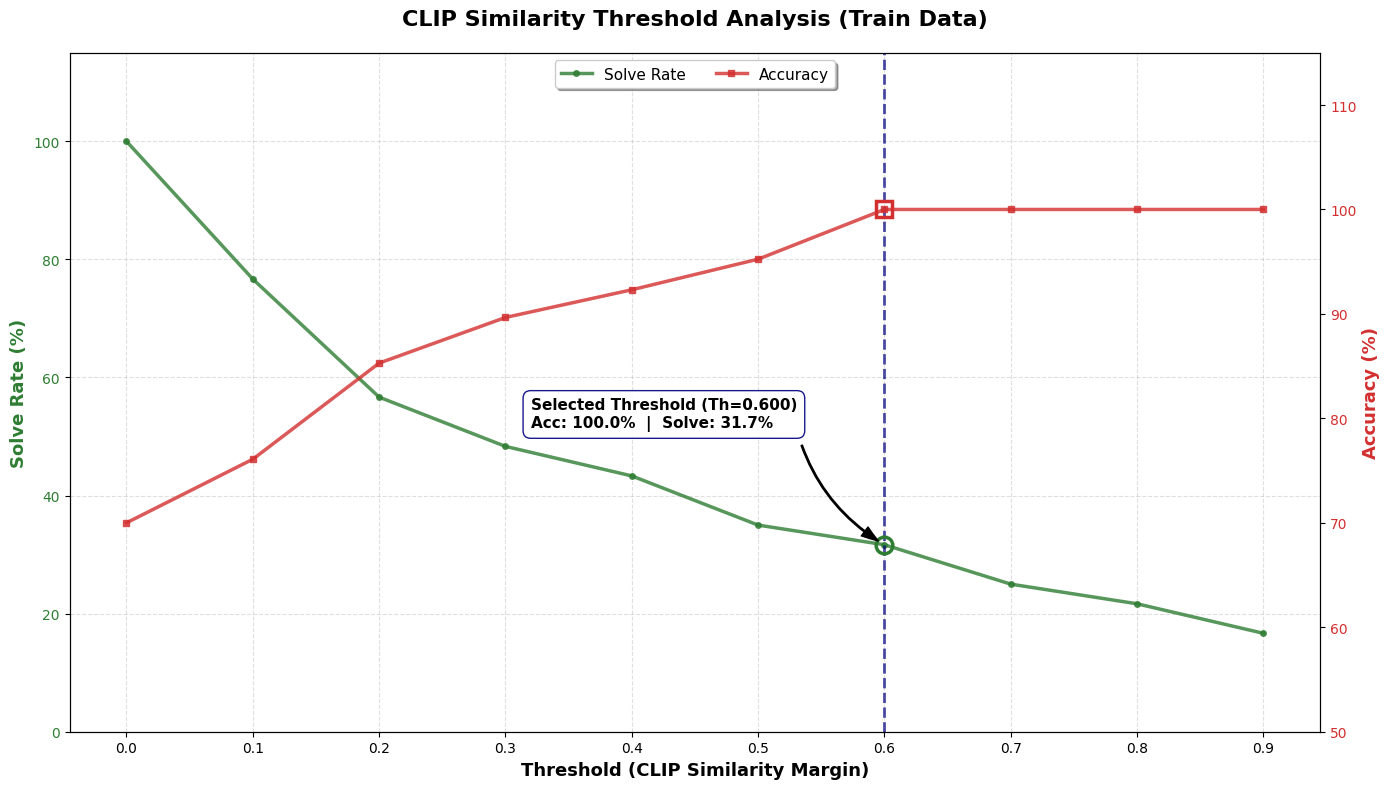

✅ 그래프 저장: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_threshold_analysis.png

 Threshold   Solve Rate   Solved   Accuracy
     0.000       100.0%       60      70.0%
     0.100        76.7%       46      76.1%
     0.200        56.7%       34      85.3%
     0.300        48.3%       29      89.7%
     0.400        43.3%       26      92.3%
     0.500        35.0%       21      95.2%
     0.600        31.7%       19     100.0% ◀ Selected
     0.700        25.0%       15     100.0%
     0.800        21.7%       13     100.0%
     0.900        16.7%       10     100.0%

  ✅ 최종 채택 Threshold : 0.600
     Accuracy : 100.0%  |  Solve Rate : 31.7%
  CSV 저장 : /content/clip_threshold_train_analysis.csv

🎯 이후 STAGE1 라우팅에 쓸 최종 THRESHOLD = 0.6


In [11]:
# =====================================================================
# Cell 9: Threshold 분석 — CLIP 유사도 기준
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def analyze_and_plot_clip(sim_csv, train_csv, start=0.0, end=0.9, step=0.1):
    sim_df = pd.read_csv(sim_csv)
    ans_df = pd.read_csv(train_csv)
    df     = pd.merge(sim_df, ans_df[['ID', 'answer']], on='ID')
    total  = len(df)

    results = []
    for th in np.arange(start, end + 1e-9, step):
        solved = correct = 0
        for _, row in df.iterrows():
            sims   = [row['Sim_A'], row['Sim_B'], row['Sim_C'], row['Sim_D']]
            s_sum  = sum(sims)
            probs  = [s / s_sum for s in sims] if s_sum else [0.25] * 4
            ranked = sorted(zip(['A', 'B', 'C', 'D'], probs), key=lambda x: x[1], reverse=True)
            margin = ranked[0][1] - ranked[1][1]
            if margin >= th:
                solved += 1
                if ranked[0][0] == str(row['answer']).strip().upper():
                    correct += 1
        results.append({
            'Threshold':  round(th, 3),
            'Solved':     solved,
            'Solve_Rate': round(solved / total * 100, 2),
            'Accuracy':   round(correct / solved * 100 if solved else 0, 2)
        })

    res_df = pd.DataFrame(results)

    # ⬅ 수정: 파일명을 CLIP 기준으로 명확히 구분 (이전 vlm_* 파일과 절대 안 섞이게)
    res_df.to_csv("/content/clip_threshold_train_analysis.csv", index=False, encoding='utf-8-sig')

    # ⬅ 수정: target_th를 하드코딩하지 않고, 실제 최적점(Best Accuracy)을 그대로 채택
    best_idx = res_df['Accuracy'].idxmax()
    best     = res_df.loc[best_idx]
    actual_th, target_acc, target_solve = best['Threshold'], best['Accuracy'], best['Solve_Rate']

    # ── 시각화 ──────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(14, 8))

    color1 = '#2E7D32'
    ax1.set_xlabel('Threshold (CLIP Similarity Margin)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Solve Rate (%)', color=color1, fontsize=13, fontweight='bold')
    line1 = ax1.plot(res_df['Threshold'], res_df['Solve_Rate'],
                     color=color1, marker='o', label='Solve Rate',
                     linewidth=2.5, markersize=4, alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, 115)
    ax1.grid(True, linestyle='--', alpha=0.4)

    color2 = '#D32F2F'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color=color2, fontsize=13, fontweight='bold')
    line2 = ax2.plot(res_df['Threshold'], res_df['Accuracy'],
                     color=color2, marker='s', label='Accuracy',
                     linewidth=2.5, markersize=4, alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(50, 115)

    # ⬅ 수정: 유일한 기준점 하나만 표시 (이전처럼 파란 점선 + 주황 별 두 개가 헷갈리게 겹치지 않도록)
    ax1.axvline(x=actual_th, color='navy', linestyle='--', linewidth=2, alpha=0.7)
    ax1.plot(actual_th, target_solve, 'o', color='#2E7D32',
             markersize=12, fillstyle='none', markeredgewidth=2.5)
    ax2.plot(actual_th, target_acc, 's', color='#D32F2F',
             markersize=12, fillstyle='none', markeredgewidth=2.5)

    ax1.annotate(
        f'Selected Threshold (Th={actual_th:.3f})\nAcc: {target_acc:.1f}%  |  Solve: {target_solve:.1f}%',
        xy=(actual_th, target_solve),
        xytext=(actual_th - 0.28, target_solve + 20),
        arrowprops=dict(facecolor='black', shrink=0.05,
                        width=1, headwidth=8, connectionstyle="arc3,rad=.2"),
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="navy", alpha=0.9)
    )

    lines  = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', frameon=True, shadow=True, ncol=2, fontsize=11)

    # ⬅ 수정: 제목에서 "MobileVLM ... VLM Logit Margin" 삭제 → 실제 신호(CLIP)로 정정
    plt.title('CLIP Similarity Threshold Analysis (Train Data)',
              fontsize=16, pad=20, fontweight='bold')
    plt.xticks(np.arange(0, end + 0.1, 0.1))
    plt.tight_layout()

    # ⬅ 수정: 저장 파일명도 clip_ 접두어로 구분, 이전 vlm_threshold_analysis.png와 겹치지 않게
    save_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_threshold_analysis.png"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✅ 그래프 저장: {save_path}")

    # ── 요약 출력 ────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"{'Threshold':>10} {'Solve Rate':>12} {'Solved':>8} {'Accuracy':>10}")
    print(f"{'='*50}")
    for th_show in np.arange(0, 1, 0.1):
        row = res_df[res_df['Threshold'] == round(th_show, 3)]
        if not row.empty:
            r      = row.iloc[0]
            marker = " ◀ Selected" if abs(row.iloc[0]['Threshold'] - actual_th) < 0.05 else ""
            print(f"{r['Threshold']:>10.3f} {r['Solve_Rate']:>11.1f}% "
                  f"{int(r['Solved']):>8d} {r['Accuracy']:>9.1f}%{marker}")
    print(f"{'='*50}")
    print(f"\n  ✅ 최종 채택 Threshold : {actual_th:.3f}")
    print(f"     Accuracy : {target_acc:.1f}%  |  Solve Rate : {target_solve:.1f}%")
    print(f"  CSV 저장 : /content/clip_threshold_train_analysis.csv")

    return res_df, actual_th

# ── 실행 ─────────────────────────────────────────────────────────────
sim_csv   = "/content/clip_similarities_train.csv"
train_csv = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv"

res_df, FINAL_THRESHOLD = analyze_and_plot_clip(
    sim_csv   = sim_csv,
    train_csv = train_csv,
    start     = 0.0, end = 0.9, step = 0.1
)

print(f"\n🎯 이후 STAGE1 라우팅에 쓸 최종 THRESHOLD = {FINAL_THRESHOLD}")

> # **STAGE 1. Clip 유사도를 활용해서 Test Data 풀기**

In [12]:
# =====================================================================
# CLIP 기반 Test 데이터 추론
# =====================================================================
import torch
import torch.nn.functional as F
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image
from transformers import CLIPTokenizer

test_csv_path  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv"
test_image_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test_input_images/"
test_df        = pd.read_csv(test_csv_path)

clip_ckpt      = "openai/clip-vit-large-patch14-336"
clip_tokenizer = CLIPTokenizer.from_pretrained(clip_ckpt)

def encode_image_clip(image_path):
    image = Image.open(image_path).convert('RGB')
    pixel_values = image_processor.preprocess(
        image, return_tensors='pt'
    )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    with torch.no_grad():
        vision_out   = _clip_vision_model(pixel_values=pixel_values)
        pooled       = vision_out.pooler_output
        image_embeds = visual_projection(pooled)
        image_embeds = F.normalize(image_embeds.float(), dim=-1)
    return image_embeds

def encode_texts_clip(texts):
    inputs = clip_tokenizer(
        texts, padding=True, truncation=True, max_length=77, return_tensors='pt'
    ).to("cuda")
    with torch.no_grad():
        text_out    = clip_text_model(**inputs)
        pooled      = text_out.pooler_output
        text_embeds = text_projection(pooled)
        text_embeds = F.normalize(text_embeds.float(), dim=-1)
    return text_embeds

def get_clip_scores(image_path, question, choices):
    if not os.path.exists(image_path):
        return [0.25, 0.25, 0.25, 0.25]
    try:
        image_embeds = encode_image_clip(image_path)
    except Exception as e:
        print(f"[이미지 인코딩 실패] {image_path}: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    texts = [f"Question: {question} Answer: {choices[k]}" for k in ['A', 'B', 'C', 'D']]
    try:
        text_embeds = encode_texts_clip(texts)
    except Exception as e:
        print(f"[텍스트 인코딩 실패]: {e}")
        return [0.25, 0.25, 0.25, 0.25]

    logit_scale_val = logit_scale.exp().float()
    logits = logit_scale_val * (image_embeds @ text_embeds.T)
    probs  = F.softmax(logits[0], dim=-1).detach().cpu().numpy()
    return probs.tolist()

records = []
print(f"🚀 [Test Dataset] {len(test_df)}개 문항 CLIP 추론 시작...")
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_path = os.path.join(test_image_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    scores   = get_clip_scores(img_path, row['Question'], choices)
    records.append({
        "ID": row["ID"],
        "Sim_A": scores[0], "Sim_B": scores[1],
        "Sim_C": scores[2], "Sim_D": scores[3]
    })

out_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_similarities_test.csv"
pd.DataFrame(records).to_csv(out_path, index=False)
print(f"\n✅ 완료! '{out_path}'에 저장되었습니다. ({len(records)}건)")

🚀 [Test Dataset] 852개 문항 CLIP 추론 시작...


100%|██████████| 852/852 [09:43<00:00,  1.46it/s]



✅ 완료! '/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_similarities_test.csv'에 저장되었습니다. (852건)


> Top1 - Top2 Margin 기반 조건부 동적 추론 구조 결정

- 참고 문헌 : Streamlining Redundant Layers to Compress Large Language Models
-  https://openreview.net/forum?id=IC5RJvRoMp

In [13]:
# =====================================================================
# Threshold 기반 CLIP 답변 확정 / 미확정 분류
# =====================================================================
import pandas as pd

THRESHOLD = FINAL_THRESHOLD

sim_csv   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_similarities_test.csv"
test_csv  = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv"

sim_df  = pd.read_csv(sim_csv)
test_df = pd.read_csv(test_csv)
df      = pd.merge(sim_df, test_df[['ID']], on='ID')

clip_solved   = []
clip_unsolved = []

for _, row in df.iterrows():
    sims   = [row['Sim_A'], row['Sim_B'], row['Sim_C'], row['Sim_D']]
    s_sum  = sum(sims)
    probs  = [s / s_sum for s in sims] if s_sum else [0.25] * 4
    ranked = sorted(zip(['A', 'B', 'C', 'D'], probs), key=lambda x: x[1], reverse=True)
    margin = ranked[0][1] - ranked[1][1]

    entry = {
        'ID':     row['ID'],
        'pred':   ranked[0][0],
        'margin': round(margin, 4),
        'prob_A': round(probs[0], 4), 'prob_B': round(probs[1], 4),
        'prob_C': round(probs[2], 4), 'prob_D': round(probs[3], 4),
    }
    if margin >= THRESHOLD:
        clip_solved.append(entry)
    else:
        clip_unsolved.append(entry)

clip_solved_df   = pd.DataFrame(clip_solved)
clip_unsolved_df = pd.DataFrame(clip_unsolved)

solved_path   = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_solved_test.csv"
unsolved_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_unsolved_test.csv"
clip_solved_df.to_csv(solved_path, index=False)
clip_unsolved_df.to_csv(unsolved_path, index=False)

total = len(df)
print(f"{'='*50}")
print(f"  Threshold     : {THRESHOLD}")
print(f"  전체 문항     : {total}")
print(f"  CLIP 확정     : {len(clip_solved_df)}  ({len(clip_solved_df)/total*100:.1f}%)")
print(f"  추가 필요     : {len(clip_unsolved_df)}  ({len(clip_unsolved_df)/total*100:.1f}%)")
print(f"{'='*50}")
print(f"\n  저장 완료: {solved_path}\n            {unsolved_path}")

  Threshold     : 0.6
  전체 문항     : 852
  CLIP 확정     : 591  (69.4%)
  추가 필요     : 261  (30.6%)

  저장 완료: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_solved_test.csv
            /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_unsolved_test.csv


# **STAGE 2. Solving remaining test data with mobile VLM**

> Prompt 1단계: 이미지 분석 (Captioning) 프롬프트
- A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <image_tokens> Analyze the image in a comprehensive and detailed manner. ASSISTANT:

> Prompt 2단계: 분석 내용을 바탕으로 퀴즈 풀기
- A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <image_tokens> Analyze the image in a comprehensive and detailed manner. ASSISTANT: [모델이 생성한 상세 분석 내용] </s>USER: {현재 문제} Choices: A. {A 내용} B. {B 내용} C. {C 내용} D. {D 내용} Answer with only the alphabet of the correct option. ASSISTANT:

In [14]:
# =====================================================================
# LoRA 학습 완료 모델 로드 (v3 — 오늘 검증된 최신 버전)
# =====================================================================
import torch, os
from transformers import GenerationConfig

final_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final_v3"
pt_path = os.path.join(final_path, "pytorch_model.bin")

if os.path.exists(pt_path):
    print(f"✅ 저장된 파일 발견: {pt_path}")
    loaded = torch.load(pt_path, map_location='cpu', weights_only=False)
    pruned_model_lora = loaded['model'].to("cuda", dtype=torch.bfloat16).eval()
    tokenizer = loaded['tokenizer']
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
else:
    print(f"❌ 저장된 파일이 없습니다: {pt_path}")

pruned_model = pruned_model_lora

_clip_wrapper = pruned_model.model.vision_tower
_mm           = pruned_model.model.mm_projector.to("cuda", dtype=torch.bfloat16)
_embed        = pruned_model.model.embed_tokens

if hasattr(_clip_wrapper, 'is_loaded') and not _clip_wrapper.is_loaded:
    _clip_wrapper.load_model()
_clip_wrapper = _clip_wrapper.to("cuda", dtype=torch.bfloat16).eval()

new_gen_config = GenerationConfig()
new_gen_config.pad_token_id = tokenizer.pad_token_id
new_gen_config.eos_token_id = tokenizer.eos_token_id
pruned_model.generation_config = new_gen_config

total = sum(p.numel() for p in pruned_model.parameters())
print(f"✅ pruned_model = pruned_model_lora (총 파라미터: {total/1e9:.4f}B)")

✅ 저장된 파일 발견: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/MobileVLM_Pruned_LoRA_Final_v3/pytorch_model.bin
✅ pruned_model = pruned_model_lora (총 파라미터: 2.8709B)


In [15]:
# =====================================================================
# 재로드된 pruned_model 검증 — 5개 샘플 실제 생성 확인
# =====================================================================
import pandas as pd

if 'full_dataset' not in dir():
    _check_df = pd.read_csv("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train.csv").head(5)
    _check_img_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/train_input_images"
else:
    _check_df = full_dataset.df.head(5)
    _check_img_dir = full_dataset.img_dir

correct_count = 0
for i, row in _check_df.iterrows():
    img_path = os.path.join(_check_img_dir, f"{row['ID']}.jpg")
    image = Image.open(img_path).convert('RGB')
    image_tensor = image_processor.preprocess(
        image, return_tensors='pt'
    )['pixel_values'].to("cuda", dtype=torch.bfloat16)
    with torch.no_grad():
        image_features = _clip_wrapper(image_tensor)
        image_features = _mm(image_features)

    conv = conv_templates["vicuna_v1"].copy()
    choices_str = f"A. {row['A']}  B. {row['B']}  C. {row['C']}  D. {row['D']}"
    user_msg = f"{DEFAULT_IMAGE_TOKEN}\nQuestion: {row['Question']}\nChoices: {choices_str}\nAnswer:"
    conv.append_message(conv.roles[0], user_msg)
    conv.append_message(conv.roles[1], None)

    input_ids = tokenizer_image_token(
        conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
    ).unsqueeze(0).to("cuda")
    ids = input_ids[0]
    pos = (ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0][0].item()
    inputs_embeds = torch.cat([
        _embed(ids[:pos]).unsqueeze(0), image_features, _embed(ids[pos+1:]).unsqueeze(0)
    ], dim=1)

    with torch.inference_mode():
        output_ids = pruned_model.generate(
            inputs_embeds=inputs_embeds, max_new_tokens=5,
            do_sample=False, use_cache=False, pad_token_id=tokenizer.pad_token_id
        )
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    is_correct = decoded.upper() == str(row['answer']).strip().upper()
    correct_count += int(is_correct)
    print(f"ID={row['ID']}  정답={row['answer']}  모델출력={repr(decoded)}  {'✅' if is_correct else '❌'}")

print(f"\n{'✅ 정상 — 다음 단계로 진행하세요' if correct_count > 0 else '🛑 여전히 문제 있음 — 결과 공유해주세요'}")

ID=TRAIN_000  정답=A  모델출력='A'  ✅
ID=TRAIN_001  정답=B  모델출력='B'  ✅
ID=TRAIN_002  정답=C  모델출력='C'  ✅
ID=TRAIN_003  정답=C  모델출력='C'  ✅
ID=TRAIN_004  정답=B  모델출력='B'  ✅

✅ 정상 — 다음 단계로 진행하세요


In [16]:
import pandas as pd
solved_df   = pd.read_csv("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_solved_test.csv")
unsolved_df = pd.read_csv("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/clip_unsolved_test.csv")
print(f"CLIP 확정: {len(solved_df)}개 / VLM 대상: {len(unsolved_df)}개 / 합계: {len(solved_df)+len(unsolved_df)}개")

CLIP 확정: 591개 / VLM 대상: 261개 / 합계: 852개


In [17]:
# =====================================================================
# STAGE2 — 검증된 LoRA 모델로 No-COT 재추론
# =====================================================================
import os, time
from tqdm import tqdm
from PIL import Image
from mobilevlm.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from mobilevlm.utils import tokenizer_image_token
from mobilevlm.conversation import conv_templates

def solve_no_cot(image_path, question, choices):
    if not os.path.exists(image_path):
        return "A"
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = image_processor.preprocess(
            image, return_tensors='pt'
        )['pixel_values'].to("cuda", dtype=torch.bfloat16)
        with torch.no_grad():
            image_features = _clip_wrapper(image_tensor)
            image_features = _mm(image_features)
    except Exception as e:
        print(f"[인코딩 실패] {image_path}: {e}")
        return "A"

    conv = conv_templates["vicuna_v1"].copy()
    choices_str = f"A. {choices['A']}  B. {choices['B']}  C. {choices['C']}  D. {choices['D']}"
    user_msg = f"{DEFAULT_IMAGE_TOKEN}\nQuestion: {question}\nChoices: {choices_str}\nAnswer:"
    conv.append_message(conv.roles[0], user_msg)
    conv.append_message(conv.roles[1], None)

    input_ids = tokenizer_image_token(
        conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
    ).unsqueeze(0).to("cuda")
    ids = input_ids[0]
    img_pos = (ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]
    if len(img_pos) > 0:
        pos = img_pos[0].item()
        inputs_embeds = torch.cat([
            _embed(ids[:pos]).unsqueeze(0), image_features, _embed(ids[pos+1:]).unsqueeze(0)
        ], dim=1)
    else:
        inputs_embeds = _embed(ids).unsqueeze(0)

    with torch.inference_mode():
        output_ids = pruned_model.generate(
            inputs_embeds=inputs_embeds, max_new_tokens=5,
            do_sample=False, use_cache=False, pad_token_id=tokenizer.pad_token_id
        )
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
    for ch in decoded:
        if ch.upper() in ['A', 'B', 'C', 'D']:
            return ch.upper()
    return "A"

test_df = pd.read_csv("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test.csv")
test_image_dir = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/test_input_images/"
target_df = test_df[test_df['ID'].isin(set(unsolved_df['ID']))].reset_index(drop=True)
print(f"🚀 검증된 LoRA 모델로 No-COT 추론 ({len(target_df)}개)...")

start = time.time()
records = []
for _, row in tqdm(target_df.iterrows(), total=len(target_df)):
    img_path = os.path.join(test_image_dir, f"{row['ID']}.jpg")
    choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
    pred = solve_no_cot(img_path, row['Question'], choices)
    records.append({"ID": row["ID"], "answer": pred})
elapsed = time.time() - start

vlm_result_df = pd.DataFrame(records)
vlm_out_path = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_lora_nocot_vlm_results.csv"
vlm_result_df.to_csv(vlm_out_path, index=False)
print(f"\n✅ 저장 완료: {vlm_out_path}")
print(f"⏱️ 총 소요시간: {elapsed:.1f}초  (문항당 평균 {elapsed/len(target_df)*1000:.1f}ms)")
print(f"예측 분포:\n{vlm_result_df['answer'].value_counts()}")

🚀 검증된 LoRA 모델로 No-COT 추론 (261개)...


100%|██████████| 261/261 [00:35<00:00,  7.40it/s]



✅ 저장 완료: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_lora_nocot_vlm_results.csv
⏱️ 총 소요시간: 35.3초  (문항당 평균 135.1ms)
예측 분포:
answer
D    83
C    63
A    62
B    53
Name: count, dtype: int64


# **Final Merge**

In [18]:
# =====================================================================
# 최종 합치기 — VERIFIED_ 접두어로 이전 파일과 완전히 분리
# =====================================================================
sample_df = pd.read_csv("/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/SCPC DATA/sample_submission.csv")
solved_answer_df = solved_df[['ID', 'pred']].rename(columns={'pred': 'answer'})

combined = pd.concat([solved_answer_df, vlm_result_df], ignore_index=True)
final_verified = sample_df[['ID']].merge(combined, on='ID', how='left')

missing = final_verified['answer'].isna().sum()
print(f"누락 문항: {missing}개")

final_out = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_final_submission.csv"
final_verified.to_csv(final_out, index=False)
print(f"✅ 최종 제출 파일: {final_out}")

누락 문항: 0개
✅ 최종 제출 파일: /content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_final_submission.csv


# **Ablation Study**

In [1]:
# # =====================================================================
# # STAGE2 — 검증된 LoRA 모델로 COT 재추론 (공정 비교용)
# # =====================================================================
# import time

# def solve_with_cot(image_path, question, choices):
#     if not os.path.exists(image_path):
#         return "A"
#     try:
#         image = Image.open(image_path).convert('RGB')
#         image_tensor = image_processor.preprocess(
#             image, return_tensors='pt'
#         )['pixel_values'].to("cuda", dtype=torch.bfloat16)
#         with torch.no_grad():
#             image_features = _clip_wrapper(image_tensor)
#             image_features = _mm(image_features)
#     except Exception as e:
#         print(f"[인코딩 실패] {image_path}: {e}")
#         return "A"

#     def run_generate(conv, max_new_tokens, do_sample, temperature=None):
#         prompt = conv.get_prompt()
#         input_ids = tokenizer_image_token(
#             prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
#         ).unsqueeze(0).to("cuda")
#         ids = input_ids[0]
#         img_positions = (ids == IMAGE_TOKEN_INDEX).nonzero(as_tuple=True)[0]
#         if len(img_positions) > 0:
#             pos = img_positions[0].item()
#             inputs_embeds = torch.cat([
#                 _embed(ids[:pos]).unsqueeze(0), image_features, _embed(ids[pos+1:]).unsqueeze(0)
#             ], dim=1)
#         else:
#             inputs_embeds = _embed(ids).unsqueeze(0)
#         gen_kwargs = dict(inputs_embeds=inputs_embeds, max_new_tokens=max_new_tokens,
#                            do_sample=do_sample, use_cache=False, pad_token_id=tokenizer.pad_token_id)
#         if do_sample and temperature is not None:
#             gen_kwargs['temperature'] = temperature
#         with torch.inference_mode():
#             output_ids = pruned_model.generate(**gen_kwargs)
#         return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

#     analysis_q = "Analyze the image in a comprehensive and detailed manner."
#     conv = conv_templates["vicuna_v1"].copy()
#     conv.append_message(conv.roles[0], f"{DEFAULT_IMAGE_TOKEN}\n{analysis_q}")
#     conv.append_message(conv.roles[1], None)
#     analysis_res = run_generate(conv, max_new_tokens=256, do_sample=True, temperature=0.7)

#     quiz_q = (
#         f"{question}\nChoices:\nA. {choices['A']}\nB. {choices['B']}\n"
#         f"C. {choices['C']}\nD. {choices['D']}\nAnswer with only the alphabet of the correct option."
#     )
#     conv.messages[-1][1] = analysis_res
#     conv.append_message(conv.roles[0], quiz_q)
#     conv.append_message(conv.roles[1], None)
#     final_answer = run_generate(conv, max_new_tokens=5, do_sample=False)

#     for ch in final_answer:
#         if ch.upper() in ['A', 'B', 'C', 'D']:
#             return ch.upper()
#     return "A"

# print(f"🚀 검증된 LoRA 모델로 COT 재추론 ({len(target_df)}개)...")
# start = time.time()
# records_cot = []
# for _, row in tqdm(target_df.iterrows(), total=len(target_df)):
#     img_path = os.path.join(test_image_dir, f"{row['ID']}.jpg")
#     choices  = {k: row[k] for k in ['A', 'B', 'C', 'D']}
#     pred = solve_with_cot(img_path, row['Question'], choices)
#     records_cot.append({"ID": row["ID"], "answer": pred})
# elapsed_cot = time.time() - start

# vlm_cot_df = pd.DataFrame(records_cot)
# vlm_cot_out = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_lora_cot_vlm_results.csv"
# vlm_cot_df.to_csv(vlm_cot_out, index=False)
# print(f"\n⏱️ COT 총 소요시간: {elapsed_cot:.1f}초  (No-COT은 {elapsed:.1f}초였음)")
# print(f"예측 분포:\n{vlm_cot_df['answer'].value_counts()}")

# # ── 최종 합치기 + 채점 ──
# combined_cot = pd.concat([solved_answer_df, vlm_cot_df], ignore_index=True)
# final_cot = sample_df[['ID']].merge(combined_cot, on='ID', how='left')
# final_cot_out = "/content/drive/MyDrive/KAIST AIME LAB/VLM Pruning/VERIFIED_final_submission_COT.csv"
# final_cot.to_csv(final_cot_out, index=False)

##  **COT(Chain-of-Thought)를 최종적으로 배제한 이유**

### 검토한 대안
- 확신도가 낮은 문항에 대해, 답을 바로 고르게 하는 대신 이미지에 대한 상세 분석(1단계)을 먼저 생성시킨 뒤 그 분석을 근거로 답하게 하는(2단계) 멀티턴 COT 구조를 시도했다.
- "고민이 필요한 문제일수록 더 깊이 추론하게 한다"는 직관에 기반한 설계였다.

### 정량적 트레이드오프 분석
- 같은 조건(동일 LoRA 모델, 동일 CLIP 라우팅)에서 COT 유무에 따른 정확도와 추론 시간을 직접 비교했다.



| | 정확도 | 문항당 평균 응답 시간 |
|---|---|---|
| No-COT (단일 턴) | 75.3% | **135ms** |
| COT (2턴, 이미지 분석 포함) | 76.5% | **4,613ms** |
| 차이 | +1.2%p | **34.1배 느림** |

### 최종 결정: No-COT 채택
- COT는 정확도를 1.2%p 개선했지만, 그 대가로 응답 시간이 34배 늘어났다(문항당 135ms → 4.6초).
- 이 프로젝트의 전제가 **스마트폰 등 온디바이스 환경에서의 실사용**이라는 점을 고려하면, 4.6초의 응답 지연은 1.2%p의 정확도 개선으로 정당화하기 어렵다고 판단해 **No-COT 구조를 최종 파이프라인으로 채택**했다.

---

# **Conclusion**

### Ablation — 공식 재제출 기준

| 구성 | Private Leader Board | 비고 |
|---|---|---|
| A. Pruning만 (라우팅 없음) | 58.0% | |
| B. +Threshold Ensemble (LoRA 없음) | 71.4% | ▲13.4%p |
| **C. +LoRA, No-COT (최종 채택)** | **75.3%** | ▲3.9%p |
| D. +LoRA, COT 포함 (참고, 미채택) | 76.5% | ▲1.2%p, 응답시간 34배 |

- 가장 큰 성능 기여는 **A→B 구간(+13.4%p)**, 즉 Top1-Top2 margin 기반 조건부 앙상블 구조 자체에서 나왔다.
- 단일 모델이 쉬운 문항과 어려운 문항을 구분 없이 처리하는 대신, 확신도에 따라 연산 자원을 차등 배분한 것이 정확도 개선의 핵심 동력이었다.

### 효율성 지표
- **파라미터 효율**: LoRA 학습 파라미터 52.7M / 전체 2.92B (**1.8%**) — Full Fine-tuning 없이 사전학습 지식 보존
- **연산 자원 분배**: 테스트 문항의 약 69%는 CLIP 경량 연산만으로 즉시 처리, 약 31%만 고연산 Pruned VLM에 투입
- **응답 속도**: 최종 채택안(No-COT) 기준 문항당 평균 135ms — 온디바이스 실시간 사용에 적합한 수준